# Serial Position Curve

> Analyze and visualize recall probability as a function of study position.

The serial position curve (SPC) is one of the most robust findings in memory research: when people study a list of items and then freely recall them, recall probability varies systematically with study position. Items from the beginning of the list (primacy) and end of the list (recency) are recalled more often than items from the middle [@murdock1962serial; @glanzer1966two].

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.spc import fixed_pres_spc, spc, plot_spc
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "SPC"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

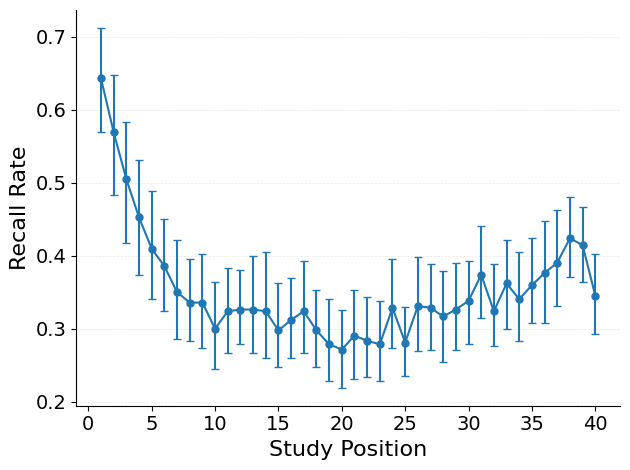

In [5]:
#| code-summary: Plot serial position curve
#| label: fig-spc
#| fig-cap: "Serial position curve showing recall probability by study position."
plot_spc(data, trial_mask)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

Each dataset is paired with its corresponding mask by index. To compare conditions within one dataset, pass the dataset multiple times with different masks: `plot_spc([data, data], [mask_a, mask_b], ...)`.

In [6]:
#| echo: false
show_doc(plot_spc)

---

### plot_spc

>      plot_spc (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr.typ
>                ing.RecallDataset], trial_masks:Union[Sequence[jaxtyping.Bool[A
>                rray,'trial_count']],jaxtyping.Bool[Array,'trial_count']],
>                color_cycle:Optional[list[str]]=None,
>                labels:Optional[Sequence[str]]=None,
>                contrast_name:Optional[str]=None,
>                axis:Optional[matplotlib.axes._axes.Axes]=None, size:int=3,
>                confidence_level:float=0.95)

*Plot serial position curves with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets. Each is paired with the mask at the same index. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. Length must match ``datasets``. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| size | int | 3 | Maximum study positions an item can occupy (default: 3). |
| confidence_level | float | 0.95 | Confidence level for error bounds (default: 0.95). |
| **Returns** | **Axes** |  | **Matplotlib Axes with serial position curves.** |

The `plot_spc` function uses `spc` internally, which handles datasets where items may appear at multiple study positions. For fixed-length lists with no repetition, `fixed_pres_spc` provides a simpler interface.

In [7]:
#| echo: false
show_doc(fixed_pres_spc)

---

### fixed_pres_spc

>      fixed_pres_spc
>                      (recalls:jaxtyping.Integer[Array,'trial_countrecall_posit
>                      ions'], list_length:int)

*Compute recall rate by study position for fixed-length lists.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| recalls | Integer[Array, 'trial_count recall_positions'] | Trial by recall position array of recalled items (1-indexed; 0 = no recall). |
| list_length | int | Number of items in the study list. |
| **Returns** | **Float[Array, 'study_positions']** | **Recall probability at each serial position.** |

In [8]:
recalls = jnp.array([
    [1, 2, 0],  # trial 1: recalled items 1 and 2
    [2, 3, 0],  # trial 2: recalled items 2 and 3
])

rates = fixed_pres_spc(recalls, list_length=3)
assert jnp.allclose(rates, jnp.array([0.5, 1.0, 0.5]))

In [9]:
#| echo: false
show_doc(spc)

---

### spc

>      spc (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Compute recall rate by study position, handling repeated items.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset containing ``recalls`` and ``pres_itemnos``. |
| size | int | 3 | Maximum study positions an item can occupy (default: 3). |
| **Returns** | **Float[Array, 'study_positions']** |  | **Recall probability at each serial position.** |

In [10]:
recalls = jnp.array([[1, 2, 0], [2, 3, 0]])
presentations = jnp.array([[1, 2, 3], [1, 2, 3]])

dataset = {
    "subject": jnp.ones((2, 1), dtype=int),
    "listLength": jnp.full((2, 1), 3, dtype=int),
    "pres_itemnos": presentations,
    "recalls": recalls,
}

rates = spc(dataset, size=1)
assert jnp.allclose(rates, jnp.array([0.5, 1.0, 0.5]))